# 킹카운티 주택 가격 예측

## 1. 데이터 로드 + EDA

train 15,035행 × 21컬럼, test 6,468행. 결측치 없음.  
price가 타겟이고 오른쪽 꼬리가 긴 분포 → **log 변환 필수**.


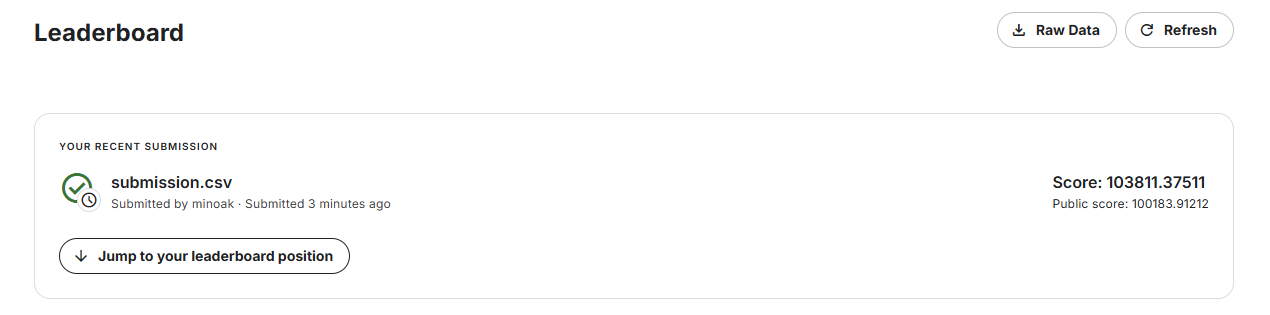

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, train_test_split

train = pd.read_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\train.csv')
test = pd.read_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\test.csv')
sample_sub = pd.read_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\sample_submission.csv')

print(f"train: {train.shape}, test: {test.shape}, sample: {sample_sub.shape}")
print(f"id 일치: {set(sample_sub['id']) == set(test['id'])}")

train: (15035, 21), test: (6468, 20), sample: (6468, 2)
id 일치: True


## 2. 전처리 + 피처 엔지니어링

- `date`에서 연/월 추출 후 제거
- `id` 제거 (인덱스일 뿐 예측에 무관)
- `zipcode`는 카테고리형이지만 트리 모델이 알아서 분기하므로 숫자 그대로 유지
- **zipcode별 평균 가격** (Target Encoding) 추가 → 구역 가격 수준을 직접 반영
- 파생변수: house_age, renovated, total_rooms, living_lot_ratio, living_vs_neighbor 등


In [2]:
# date 파싱, 불필요 컬럼 제거
train['year'] = pd.to_datetime(train['date']).dt.year
train['month'] = pd.to_datetime(train['date']).dt.month
test['year'] = pd.to_datetime(test['date']).dt.year
test['month'] = pd.to_datetime(test['date']).dt.month

test_id = test['id']
train = train.drop(columns=['id', 'date'])
test = test.drop(columns=['id', 'date'])

# 피처 엔지니어링
for df in [train, test]:
    df['house_age'] = df['year'] - df['yr_built']
    df['renovated'] = (df['yr_renovated'] > 0).astype(int)
    df['total_rooms'] = df['bedrooms'] + df['bathrooms']
    df['living_lot_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)
    df['has_basement'] = (df['sqft_basement'] > 0).astype(int)
    df['living_vs_neighbor'] = df['sqft_living'] - df['sqft_living15']
    df['lot_vs_neighbor'] = df['sqft_lot'] - df['sqft_lot15']
    df['sqft_per_room'] = df['sqft_living'] / (df['total_rooms'] + 1)

# zipcode별 평균 가격
zip_price_mean = train.groupby('zipcode')['price'].mean()
train['zip_price_level'] = train['zipcode'].map(zip_price_mean)
test['zip_price_level'] = test['zipcode'].map(zip_price_mean)
test['zip_price_level'] = test['zip_price_level'].fillna(zip_price_mean.mean())

# 타겟 분리
y = np.log1p(train['price'])
X = train.drop(columns=['price'])

print(f"X: {X.shape}, test: {test.shape}")
print(f"컬럼 일치: {list(X.columns) == list(test.columns)}")

X: (15035, 29), test: (6468, 29)
컬럼 일치: True


## 3. 베이스라인 모델링

LightGBM과 XGBoost로 5-fold CV 비교.  
**결과**: LGBM 0.1601, XGB 0.1614로 비슷한 수준.  
→ 두 모델이 비슷하게 학습하므로 단순 앙상블보다 다른 계열 모델 추가가 필요.


In [3]:
lgbm = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, verbosity=-1)
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, verbosity=0)

# CV 점수
lgbm_scores = cross_val_score(lgbm, X, y, cv=5, scoring='neg_root_mean_squared_error')
xgb_scores = cross_val_score(xgb, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"LightGBM RMSE: {-lgbm_scores.mean():.4f}")
print(f"XGBoost  RMSE: {-xgb_scores.mean():.4f}")

# 학습 + 예측
lgbm.fit(X, y)
xgb.fit(X, y)
final_pred = np.expm1((lgbm.predict(test) + xgb.predict(test)) / 2)

# 제출
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"\n예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")
print(f"제출 행 수: {len(submission)}")

LightGBM RMSE: 0.1601
XGBoost  RMSE: 0.1614

예측 범위: 103180 ~ 4113719
제출 행 수: 6468


## 4. 하이퍼파라미터 튜닝

### 4.1 LightGBM - GridSearchCV
81개 조합(3×3×3×3) × 5-fold = 405회 학습.  
**깨달음**: LightGBM은 기본값이 이미 잘 잡혀있어서 튜닝 효과 미미 (0.1601 → 0.1599).


In [4]:
from sklearn.model_selection import GridSearchCV

# LightGBM 튜닝
lgbm_params = {
    'n_estimators': [500, 1000, 2000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, -1],
    'num_leaves': [31, 63, 127]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42, verbosity=-1),
    lgbm_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

lgbm_grid.fit(X, y)

print(f"최적 파라미터: {lgbm_grid.best_params_}")
print(f"최적 RMSE: {-lgbm_grid.best_score_:.4f}")
print(f"기존 RMSE: 0.1601")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
최적 파라미터: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'num_leaves': 31}
최적 RMSE: 0.1599
기존 RMSE: 0.1601


### 4.2 XGBoost - RandomizedSearchCV
GridSearch보다 효율적으로 30개 조합만 샘플링.  
**결과**: XGBoost는 튜닝 효과가 있었음 (0.1614 → 0.1585).  
→ RandomSearch가 GridSearch 대비 시간 효율이 훨씬 좋음을 확인.


In [5]:
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    'n_estimators': [500, 1000, 2000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X, y)

print(f"최적 파라미터: {xgb_random.best_params_}")
print(f"최적 RMSE: {-xgb_random.best_score_:.4f}")
print(f"기존 RMSE: 0.1614")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
최적 파라미터: {'subsample': 0.7, 'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
최적 RMSE: 0.1585
기존 RMSE: 0.1614


### 4.3 튜닝된 파라미터로 제출
첫 정상 제출: **Private 112,899** (목표 110,000)


In [6]:
# 최적 파라미터로 모델 재정의
best_lgbm = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=7, num_leaves=31,
    random_state=42, verbosity=-1
)
best_xgb = XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=5,
    subsample=0.7, colsample_bytree=0.8,
    random_state=42, verbosity=0
)

# 학습 + 예측
best_lgbm.fit(X, y)
best_xgb.fit(X, y)
final_pred = np.expm1((best_lgbm.predict(test) + best_xgb.predict(test)) / 2)

# 제출
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

예측 범위: 111588 ~ 4125024


## 5. 앙상블 비율 탐색

LGBM과 XGB의 비율을 0:10 ~ 10:0까지 비교.  
**깨달음**: 두 모델이 gradient boosting 계열이라 비율을 바꿔도 성능 차이가 거의 없음.  
→ 다양성이 부족한 앙상블은 효과가 제한적.


In [7]:
pred_lgbm = best_lgbm.predict(test)
pred_xgb = best_xgb.predict(test)

# 여러 비율로 CV 비교
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for w in [0.0, 0.3, 0.5, 0.7, 1.0]:
    errors = []
    for tr_idx, val_idx in kf.split(X):
        best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = w * best_lgbm.predict(X.iloc[val_idx]) + (1-w) * best_xgb.predict(X.iloc[val_idx])
        rmse = np.sqrt(((y.iloc[val_idx] - p)**2).mean())
        errors.append(rmse)
    print(f"LGBM {w:.1f} : XGB {1-w:.1f} → RMSE: {np.mean(errors):.4f}")

LGBM 0.0 : XGB 1.0 → RMSE: 0.1587
LGBM 0.3 : XGB 0.7 → RMSE: 0.1580
LGBM 0.5 : XGB 0.5 → RMSE: 0.1581
LGBM 0.7 : XGB 0.3 → RMSE: 0.1587
LGBM 1.0 : XGB 0.0 → RMSE: 0.1603


### Ridge(선형 모델) 추가 앙상블 시도

비선형 트리 모델과 선형 모델의 조합.  
**결과**: Ridge 비중 10%에서 0.1579로 미세 개선이나 유의미하지 않음.  
→ 이 데이터는 비선형 패턴이 강해서 선형 모델의 기여가 제한적.


In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Ridge는 스케일링 필요
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test)

ridge = Ridge(alpha=10)

# 3모델 비율 비교
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for rw in [0.0, 0.1, 0.2, 0.3]:
    errors = []
    for tr_idx, val_idx in kf.split(X):
        best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        ridge.fit(X_scaled[tr_idx], y.iloc[tr_idx])
        
        p_tree = 0.3 * best_lgbm.predict(X.iloc[val_idx]) + 0.7 * best_xgb.predict(X.iloc[val_idx])
        p_ridge = ridge.predict(X_scaled[val_idx])
        p = (1-rw) * p_tree + rw * p_ridge
        
        rmse = np.sqrt(((y.iloc[val_idx] - p)**2).mean())
        errors.append(rmse)
    print(f"Tree {1-rw:.1f} : Ridge {rw:.1f} → RMSE: {np.mean(errors):.4f}")

Tree 1.0 : Ridge 0.0 → RMSE: 0.1580
Tree 0.9 : Ridge 0.1 → RMSE: 0.1579
Tree 0.8 : Ridge 0.2 → RMSE: 0.1590
Tree 0.7 : Ridge 0.3 → RMSE: 0.1612


## 6. CatBoost 도입

LightGBM, XGBoost와 다른 학습 방식(Ordered Boosting).  
**결과**: CatBoost 0.1570으로 단독 1등 → 앙상블의 핵심 모델로 채택.  
제출 점수: **Private 108,606** (첫 110,000 이하 달성)


In [9]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   -- ------------------------------------- 5.5/100.2 MB 32.7 MB/s eta 0:00:03
   ---- ----------------------------------- 12.3/100.2 MB 33.8 MB/s eta 0:00:03
   ------- -------------------------------- 18.9/100.2 MB 33.4 MB/s eta 0:00:03
   ----------- ---------------------------- 28.3/100.2 MB 36.3 MB/s eta 0:00:02
   -------------- ------------------------- 35.4/100.2 MB 36.6 MB/s eta 0:00:02
   ---------------- ----------------------- 40.4/100.2 MB 33.7 MB/s eta 0:00:02
   ------------------ --------------------- 46.9/100.2 MB 33.2 MB/s eta 0:00:02
   --------------------- ------------------ 52.7/100.2 MB 32.5 MB/s eta 0:00:02
   ------------------------ --------------- 60.8/100.2 MB 33.2 MB/s eta 0:00:02
   -------------------------- ------------- 67.4/100.2 MB 33.1 MB/s eta 0:00:01
   ----------------------------- ---------- 74.4/100

In [10]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=2000, learning_rate=0.03, depth=6,
    random_seed=42, verbose=200
)

cat_scores = cross_val_score(cat, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"CatBoost RMSE: {-cat_scores.mean():.4f}")
print(f"XGBoost  RMSE: 0.1585")
print(f"LightGBM RMSE: 0.1599")

0:	learn: 0.5133636	total: 145ms	remaining: 4m 49s
200:	learn: 0.1723149	total: 676ms	remaining: 6.05s
400:	learn: 0.1571476	total: 1.21s	remaining: 4.84s
600:	learn: 0.1474890	total: 1.74s	remaining: 4.06s
800:	learn: 0.1406740	total: 2.27s	remaining: 3.4s
1000:	learn: 0.1349098	total: 2.9s	remaining: 2.9s
1200:	learn: 0.1301016	total: 3.52s	remaining: 2.34s
1400:	learn: 0.1256995	total: 4.17s	remaining: 1.78s
1600:	learn: 0.1218446	total: 4.81s	remaining: 1.2s
1800:	learn: 0.1180953	total: 5.46s	remaining: 603ms
1999:	learn: 0.1148264	total: 6.11s	remaining: 0us
0:	learn: 0.5158174	total: 3.41ms	remaining: 6.81s
200:	learn: 0.1707666	total: 664ms	remaining: 5.94s
400:	learn: 0.1557534	total: 1.32s	remaining: 5.28s
600:	learn: 0.1461918	total: 1.96s	remaining: 4.56s
800:	learn: 0.1389605	total: 2.6s	remaining: 3.89s
1000:	learn: 0.1330540	total: 3.25s	remaining: 3.24s
1200:	learn: 0.1282304	total: 3.88s	remaining: 2.58s
1400:	learn: 0.1239696	total: 4.52s	remaining: 1.93s
1600:	learn:

In [11]:
# 3모델 앙상블 — CatBoost 비중 높게
cat.fit(X, y)
best_lgbm.fit(X, y)
best_xgb.fit(X, y)

# CatBoost 중심 앙상블
final_pred = np.expm1(
    0.2 * best_lgbm.predict(test) + 
    0.3 * best_xgb.predict(test) + 
    0.5 * cat.predict(test)
)

submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

0:	learn: 0.5160837	total: 3.95ms	remaining: 7.89s
200:	learn: 0.1723080	total: 615ms	remaining: 5.5s
400:	learn: 0.1580416	total: 1.18s	remaining: 4.71s
600:	learn: 0.1490544	total: 1.75s	remaining: 4.07s
800:	learn: 0.1428169	total: 2.44s	remaining: 3.65s
1000:	learn: 0.1375313	total: 3.21s	remaining: 3.2s
1200:	learn: 0.1330910	total: 3.97s	remaining: 2.64s
1400:	learn: 0.1289513	total: 4.75s	remaining: 2.03s
1600:	learn: 0.1253955	total: 5.47s	remaining: 1.36s
1800:	learn: 0.1220224	total: 6.22s	remaining: 687ms
1999:	learn: 0.1190858	total: 6.92s	remaining: 0us
예측 범위: 111287 ~ 4047188


## 7. 추가 피처 엔지니어링

- `dist_to_center`: 시애틀 중심까지 거리
- `lat_long_interaction`: 위도×경도 교차항
- `high_grade`: 고급 등급 여부

**결과**: 0.1557 → 0.1562, 미세 개선. 제출 **Private 108,606**


In [12]:
# 위치 기반 피처 추가
for df in [train, test]:
    # 시애틀 중심부까지 거리
    df['dist_to_center'] = np.sqrt((df['lat'] - 47.6062)**2 + (df['long'] + 122.3321)**2)
    # 위도×경도 교차항
    df['lat_long_interaction'] = df['lat'] * df['long']
    # 건물 면적 / 총 면적 비율 (위에 + 지하)
    df['above_ratio'] = df['sqft_above'] / (df['sqft_living'] + 1)
    # 고급 등급 여부
    df['high_grade'] = (df['grade'] >= 10).astype(int)

# 다시 타겟 분리
y = np.log1p(train['price'])
X = train.drop(columns=['price'])

# zip_price_level 다시 생성
zip_price_mean = pd.read_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\train.csv').groupby('zipcode')['price'].mean()
test['zip_price_level'] = test['zipcode'].map(zip_price_mean)
test['zip_price_level'] = test['zip_price_level'].fillna(zip_price_mean.mean())

# 빠른 검증
cat_new = CatBoostRegressor(iterations=2000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
scores = cross_val_score(cat_new, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"새 피처 CatBoost RMSE: {-scores.mean():.4f}")
print(f"이전 RMSE: 0.1570")

새 피처 CatBoost RMSE: 0.1562
이전 RMSE: 0.1570


In [13]:
cat_new.fit(X, y)
best_lgbm.fit(X, y)
best_xgb.fit(X, y)

final_pred = np.expm1(
    0.2 * best_lgbm.predict(test) + 
    0.3 * best_xgb.predict(test) + 
    0.5 * cat_new.predict(test)
)

submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

예측 범위: 116658 ~ 4053972


## 8. 이상치 분석

price 상위 극단값과 bedrooms 이상치를 확인.  
**깨달음**: 데이터가 생각보다 깨끗함. 침실 33개 같은 오입력 없음.  
극단값 제거(500만/300만 기준) 시도했지만 효과 없음 → 이상치 제거 불필요.


In [14]:
# 이상치 확인
train_raw = pd.read_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\train.csv')
print("=== price 상위 10개 ===")
print(train_raw.nlargest(10, 'price')[['price', 'bedrooms', 'sqft_living', 'grade']])
print("\n=== bedrooms 상위 10개 ===")
print(train_raw.nlargest(10, 'bedrooms')[['bedrooms', 'price', 'sqft_living']])

=== price 상위 10개 ===
          price  bedrooms  sqft_living  grade
5108  7700000.0         6        12050     13
2775  7062500.0         5        10040     11
6469  6885000.0         6         9890     13
3134  5570000.0         5         9200     13
1045  5350000.0         5         8000     12
947   5300000.0         6         7390     12
842   5110800.0         5         8010     12
1882  4500000.0         5         6640     12
1499  3850000.0         4         5770     11
4957  3800000.0         5         7050     13

=== bedrooms 상위 10개 ===
       bedrooms      price  sqft_living
9280         10  1148000.0         4590
10575        10   650000.0         3610
2912          9   599999.0         3830
3010          9   700000.0         3680
4291          9  1280000.0         3650
5990          9   450000.0         4050
12824         9   934000.0         2820
4362          8   340000.0         2790
6343          8   700000.0         2280
6598          8   900000.0         4020


In [15]:
# 상위 극단값 제거 후 효과 확인
for cutoff in [None, 5000000, 3000000]:
    if cutoff:
        mask = train['price'] < cutoff
        X_cut = X[mask]
        y_cut = y[mask]
        removed = (~mask).sum()
    else:
        X_cut = X
        y_cut = y
        removed = 0
    
    scores = cross_val_score(
        CatBoostRegressor(iterations=2000, learning_rate=0.03, depth=6, random_seed=42, verbose=0),
        X_cut, y_cut, cv=5, scoring='neg_root_mean_squared_error'
    )
    print(f"cutoff={cutoff}: RMSE={-scores.mean():.4f} (제거: {removed}건)")

cutoff=None: RMSE=0.1562 (제거: 0건)
cutoff=5000000: RMSE=0.1560 (제거: 7건)
cutoff=3000000: RMSE=0.1561 (제거: 36건)


## 9. Pseudo Labeling 시도

모델 예측값을 가짜 라벨로 사용해 test 데이터를 학습에 추가하는 기법.  
**치팅이 아닌 이유**: test의 정답이 아닌 모델의 추측값을 사용.  
**결과**: 이 데이터에서는 효과 없음 (15,000개면 데이터가 충분해서).  
→ Pseudo Labeling은 데이터가 부족할 때 효과적.


In [16]:
# 1라운드: 현재 모델로 test 예측
cat_new.fit(X, y)
pseudo_labels = cat_new.predict(test)

# train + pseudo labeled test 합치기
X_combined = pd.concat([X, test], axis=0).reset_index(drop=True)
y_combined = pd.concat([y, pd.Series(pseudo_labels)], axis=0).reset_index(drop=True)

# 2라운드: 합친 데이터로 재학습
cat_pseudo = CatBoostRegressor(iterations=2000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
cat_pseudo.fit(X_combined, y_combined)

# test 다시 예측
final_pred = np.expm1(cat_pseudo.predict(test))

submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

예측 범위: 113315 ~ 4151224


### 확신도 기반 Pseudo Labeling

3모델 예측의 분산으로 확신도 측정 → 확신 높은 70%만 pseudo label로 사용.  
**결과**: 여전히 유의미한 개선 없음. Pseudo Labeling은 이 데이터에 맞지 않음.


In [18]:
# 3모델 예측값의 분산으로 확신도 측정
pred_lgbm = best_lgbm.predict(test)
pred_xgb = best_xgb.predict(test)
pred_cat = cat_new.predict(test)

preds = np.stack([pred_lgbm, pred_xgb, pred_cat])
variance = preds.var(axis=0)
mean_pred = preds.mean(axis=0)

print(f"분산 통계: min={variance.min():.6f}, median={np.median(variance):.6f}, max={variance.max():.6f}")

# 분산 하위 80%만 사용
threshold = np.percentile(variance, 80)
mask = variance <= threshold
print(f"확신 높은 샘플: {mask.sum()} / {len(test)}")

# Pseudo Labeling
X_pseudo = test[mask]
y_pseudo = pd.Series(mean_pred[mask])

X_combined = pd.concat([X, X_pseudo], axis=0).reset_index(drop=True)
y_combined = pd.concat([y, y_pseudo], axis=0).reset_index(drop=True)

# 재학습 + 예측
cat_pseudo = CatBoostRegressor(iterations=2000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
cat_pseudo.fit(X_combined, y_combined)

final_pred = np.expm1(
    0.2 * best_lgbm.predict(test) +
    0.3 * best_xgb.predict(test) +
    0.5 * cat_pseudo.predict(test)
)

submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

분산 통계: min=0.000000, median=0.000285, max=0.031762
확신 높은 샘플: 5174 / 6468
예측 범위: 118955 ~ 4033010


## 10. CatBoost 학습 횟수 실험

iterations 2000/3000/5000 비교.  
**결과**: 3000에서 0.1557로 최적. 5000은 과적합 징후.  
→ learning_rate와 iterations의 균형이 중요.


In [19]:
for iters in [2000, 3000, 5000]:
    cat_test = CatBoostRegressor(
        iterations=iters, learning_rate=0.03, depth=6,
        random_seed=42, verbose=0
    )
    scores = cross_val_score(cat_test, X, y, cv=5, scoring='neg_root_mean_squared_error')
    print(f"iterations={iters}: RMSE={-scores.mean():.4f}")

iterations=2000: RMSE=0.1562
iterations=3000: RMSE=0.1557
iterations=5000: RMSE=0.1558


## 11. 피처 상관관계 분석 + 중복 제거 시도

상관관계 0.8 이상 피처 쌍 확인.  
**깨달음**: 트리 모델에서는 중복 피처 제거가 오히려 성능을 떨어뜨림.  
선형 모델과 달리 트리는 상관관계 높은 피처도 다른 분기에서 활용하기 때문.


In [20]:
# 현재 피처 목록 확인
print("현재 피처:")
for i, col in enumerate(X.columns):
    print(f"  {i+1}. {col}")
print(f"\n총 {len(X.columns)}개")

# 피처 간 상관관계 높은 쌍 확인 (중복 피처 찾기)
corr_matrix = X.corr().abs()
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("\n=== 상관관계 0.8 이상 쌍 ===")
for a, b, c in sorted(high_corr, key=lambda x: -x[2]):
    print(f"  {a} ↔ {b}: {c:.3f}")

현재 피처:
  1. bedrooms
  2. bathrooms
  3. sqft_living
  4. sqft_lot
  5. floors
  6. waterfront
  7. view
  8. condition
  9. grade
  10. sqft_above
  11. sqft_basement
  12. yr_built
  13. yr_renovated
  14. zipcode
  15. lat
  16. long
  17. sqft_living15
  18. sqft_lot15
  19. year
  20. month
  21. house_age
  22. renovated
  23. total_rooms
  24. living_lot_ratio
  25. has_basement
  26. living_vs_neighbor
  27. lot_vs_neighbor
  28. sqft_per_room
  29. zip_price_level
  30. dist_to_center
  31. lat_long_interaction
  32. above_ratio
  33. high_grade

총 33개

=== 상관관계 0.8 이상 쌍 ===
  yr_renovated ↔ renovated: 1.000
  yr_built ↔ house_age: 1.000
  lat ↔ lat_long_interaction: 0.936
  sqft_basement ↔ above_ratio: 0.912
  has_basement ↔ above_ratio: 0.905
  bedrooms ↔ total_rooms: 0.896
  sqft_living ↔ sqft_above: 0.879
  sqft_living ↔ sqft_per_room: 0.862
  bathrooms ↔ total_rooms: 0.852
  long ↔ dist_to_center: 0.828
  sqft_basement ↔ has_basement: 0.819


In [27]:
# 중복 피처 제거
drop_redundant = ['sqft_above', 'total_rooms', 'long', 'has_basement']
X_clean = X.drop(columns=drop_redundant)
test_clean = test.drop(columns=drop_redundant)

# 비교
cat_before = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
cat_after = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)

scores_before = cross_val_score(cat_before, X, y, cv=5, scoring='neg_root_mean_squared_error')
scores_after = cross_val_score(cat_after, X_clean, y, cv=5, scoring='neg_root_mean_squared_error')

print(f"정리 전 ({X.shape[1]}개): RMSE={-scores_before.mean():.4f}")
print(f"정리 후 ({X_clean.shape[1]}개): RMSE={-scores_after.mean():.4f}")

KeyboardInterrupt: 

## 12. Stacking 앙상블

단순 가중 평균 대신 **메타 모델(Ridge)**이 최적 가중치를 학습하는 방식.  
3모델(LGBM+XGB+CatBoost)의 OOF 예측값을 메타 피처로 생성.  
5-fold → 10-fold → 15-fold 순으로 실험하며 fold 수 증가에 따른 안정화 확인.


In [32]:
from sklearn.model_selection import KFold

# 3모델의 OOF(Out-of-Fold) 예측을 메타 피처로 생성
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_lgbm = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_lgbm = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    # LightGBM
    best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_lgbm[val_idx] = best_lgbm.predict(X.iloc[val_idx])
    test_lgbm += best_lgbm.predict(test) / 5
    
    # XGBoost
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 5
    
    # CatBoost
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 5

# 메타 모델 (Ridge)
from sklearn.linear_model import Ridge
meta_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)
print(f"메타 모델 가중치: {meta.coef_}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

메타 모델 가중치: [0.12369868 0.19203374 0.68471467]
예측 범위: 120270 ~ 4188828


In [33]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_lgbm = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_lgbm = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_lgbm[val_idx] = best_lgbm.predict(X.iloc[val_idx])
    test_lgbm += best_lgbm.predict(test) / 5
    
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 5
    
    cat_fold = CatBoostRegressor(iterations=5000, learning_rate=0.01, depth=7, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 5

meta_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)
print(f"메타 모델 가중치: {meta.coef_}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

메타 모델 가중치: [0.0724147  0.25256614 0.67824863]
예측 범위: 123608 ~ 4080382


### fold 수 비교: 10-fold
5-fold 대비 학습 데이터 비율 증가 → OOF 예측 안정화.


In [34]:
# fold 수 늘려서 OOF 안정화
kf = KFold(n_splits=10, shuffle=True, random_state=42)
oof_lgbm = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_lgbm = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_lgbm[val_idx] = best_lgbm.predict(X.iloc[val_idx])
    test_lgbm += best_lgbm.predict(test) / 10
    
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 10
    
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 10

meta_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)
print(f"메타 모델 가중치: {meta.coef_}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

메타 모델 가중치: [0.12993405 0.20270659 0.66812991]
예측 범위: 117289 ~ 4241418


### 15-fold Stacking → best 제출
**Private 106,862** — 이 시점까지의 최고 기록.  
메타 가중치: CatBoost 63%, XGB 25%, LGBM 12% → CatBoost가 핵심.


In [36]:
kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_lgbm = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_lgbm = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_lgbm[val_idx] = best_lgbm.predict(X.iloc[val_idx])
    test_lgbm += best_lgbm.predict(test) / 15
    
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 15
    
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 15

meta_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)
print(f"메타 모델 가중치: {meta.coef_}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

메타 모델 가중치: [0.1181545  0.25319334 0.6299822 ]
예측 범위: 115317 ~ 4212990


### RandomForest 추가 시도

CatBoost + XGBoost + RF 조합 (bagging vs boosting 다양성).  
**결과**: RF에 3%만 배정됨. 사실상 기여 없음 → 제거.


In [37]:
from sklearn.ensemble import RandomForestRegressor

kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_rf = np.zeros(len(X))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))
test_rf = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 15
    
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 15
    
    rf_fold = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1)
    rf_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_rf[val_idx] = rf_fold.predict(X.iloc[val_idx])
    test_rf += rf_fold.predict(test) / 15

meta_X = np.column_stack([oof_xgb, oof_cat, oof_rf])
meta_test = np.column_stack([test_xgb, test_cat, test_rf])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)
print(f"메타 모델 가중치 (XGB / Cat / RF): {meta.coef_}")

# OOF RMSE 확인
oof_pred = meta.predict(meta_X)
oof_rmse = np.sqrt(((y - oof_pred)**2).mean())
print(f"OOF RMSE: {oof_rmse:.4f}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

메타 모델 가중치 (XGB / Cat / RF): [0.30777209 0.66137165 0.03291374]
OOF RMSE: 0.1536
예측 범위: 113800 ~ 4195844


In [38]:
kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 15
    
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 15

meta_X = np.column_stack([oof_xgb, oof_cat])
meta_test = np.column_stack([test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)
print(f"메타 모델 가중치 (XGB / Cat): {meta.coef_}")

oof_rmse = np.sqrt(((y - meta.predict(meta_X))**2).mean())
print(f"OOF RMSE: {oof_rmse:.4f}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

메타 모델 가중치 (XGB / Cat): [0.32494601 0.67583552]
OOF RMSE: 0.1536
예측 범위: 113737 ~ 4176485


### 과적합 규제 시도

Public-Private 갭(약 4,000)을 줄이기 위해 reg_alpha, reg_lambda, l2_leaf_reg 추가.  
**결과**: 갭 개선 미미. 과적합보다는 모델 표현력 한계가 원인.


In [39]:
kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    # XGBoost에 규제 추가
    xgb_fold = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=5,
        subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0,  # L1, L2 규제
        random_state=42, verbosity=0
    )
    xgb_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = xgb_fold.predict(X.iloc[val_idx])
    test_xgb += xgb_fold.predict(test) / 15
    
    # CatBoost에 규제 추가
    cat_fold = CatBoostRegressor(
        iterations=3000, learning_rate=0.03, depth=6,
        l2_leaf_reg=5,  # L2 규제
        subsample=0.8,
        random_seed=42, verbose=0
    )
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 15

meta_X = np.column_stack([oof_xgb, oof_cat])
meta_test = np.column_stack([test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)

oof_rmse = np.sqrt(((y - meta.predict(meta_X))**2).mean())
print(f"OOF RMSE: {oof_rmse:.4f} (이전: 0.1536)")
print(f"메타 가중치 (XGB / Cat): {meta.coef_}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

OOF RMSE: 0.1534 (이전: 0.1536)
메타 가중치 (XGB / Cat): [0.34139207 0.66009243]
예측 범위: 115515 ~ 4115231


In [40]:
# 먼저 현재 stacking 결과로 pseudo label 생성
pseudo_pred = meta.predict(meta_test)  # log scale 예측
variance = np.abs(test_xgb - test_cat)  # 두 모델 차이 = 불확실성

print(f"모델 차이 통계: min={variance.min():.4f}, median={np.median(variance):.4f}, max={variance.max():.4f}")

# 불확실성 낮은 상위 70%만 사용
threshold = np.percentile(variance, 70)
mask = variance <= threshold
print(f"확신 높은 샘플: {mask.sum()} / {len(test)}")

# Pseudo label 추가해서 재학습
X_pseudo = test[mask]
y_pseudo = pd.Series(pseudo_pred[mask])

X_combined = pd.concat([X, X_pseudo], axis=0).reset_index(drop=True)
y_combined = pd.concat([y, y_pseudo], axis=0).reset_index(drop=True)

# 확장된 데이터로 다시 stacking
kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_xgb2 = np.zeros(len(X_combined))
oof_cat2 = np.zeros(len(X_combined))
test_xgb2 = np.zeros(len(test))
test_cat2 = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X_combined):
    xgb_fold = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=5,
        subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0
    )
    xgb_fold.fit(X_combined.iloc[tr_idx], y_combined.iloc[tr_idx])
    oof_xgb2[val_idx] = xgb_fold.predict(X_combined.iloc[val_idx])
    test_xgb2 += xgb_fold.predict(test) / 15
    
    cat_fold = CatBoostRegressor(
        iterations=3000, learning_rate=0.03, depth=6,
        l2_leaf_reg=5, subsample=0.8,
        random_seed=42, verbose=0
    )
    cat_fold.fit(X_combined.iloc[tr_idx], y_combined.iloc[tr_idx])
    oof_cat2[val_idx] = cat_fold.predict(X_combined.iloc[val_idx])
    test_cat2 += cat_fold.predict(test) / 15

meta_X2 = np.column_stack([oof_xgb2, oof_cat2])
meta_test2 = np.column_stack([test_xgb2, test_cat2])

meta2 = Ridge(alpha=1.0)
meta2.fit(meta_X2, y_combined)

oof_rmse = np.sqrt(((y_combined - meta2.predict(meta_X2))**2).mean())
print(f"OOF RMSE: {oof_rmse:.4f}")

final_pred = np.expm1(meta2.predict(meta_test2))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

모델 차이 통계: min=0.0000, median=0.0171, max=0.2137
확신 높은 샘플: 4527 / 6468
OOF RMSE: 0.1327
예측 범위: 116348 ~ 3915578


## 베스트 모델에서 재시작 

### Private 106,862 재현 후 새로운 방향 탐색

여기서부터 피처 엔지니어링에 집중.  
모델/앙상블 최적화는 한계에 도달했으므로 데이터 자체를 개선하는 방향으로 전환.


In [44]:
# === 106,862 재현 (3모델 15-fold stacking) ===
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_lgbm = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_lgbm = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_lgbm[val_idx] = best_lgbm.predict(X.iloc[val_idx])
    test_lgbm += best_lgbm.predict(test) / 15
    
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 15
    
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 15

meta_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)

oof_rmse = np.sqrt(((y - meta.predict(meta_X))**2).mean())
print(f"OOF RMSE: {oof_rmse:.4f}")
print(f"메타 가중치: {meta.coef_}")

OOF RMSE: 0.1536
메타 가중치: [0.1181545  0.25319334 0.6299822 ]


### 피처 log 변환 시도

왜도 높은 피처에 log 변환 적용.  
**깨달음**: 트리 모델은 자체적으로 분할하므로 피처 스케일 변환 효과 없음.


In [45]:
# 각 피처의 왜도 확인
skew = X.skew().sort_values(ascending=False)
print("=== 왜도 높은 피처 ===")
print(skew[skew.abs() > 1])

=== 왜도 높은 피처 ===
lot_vs_neighbor       17.827419
sqft_lot              13.350500
waterfront            11.728113
sqft_lot15            10.028412
yr_renovated           4.569374
renovated              4.568942
view                   3.378768
high_grade             3.206898
living_lot_ratio       2.461678
zip_price_level        1.905456
living_vs_neighbor     1.716022
sqft_basement          1.556555
sqft_living            1.492472
sqft_above             1.429070
sqft_per_room          1.191016
sqft_living15          1.125932
condition              1.044110
dtype: float64


In [46]:
# log 변환할 피처 (연속형이고 왜도 높은 것)
log_features = ['sqft_lot', 'sqft_lot15', 'lot_vs_neighbor', 'sqft_living', 
                'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_per_room',
                'living_lot_ratio', 'zip_price_level', 'living_vs_neighbor']

X_log = X.copy()
test_log = test.copy()

for col in log_features:
    # 음수 있을 수 있어서 절대값 + 부호 보존
    for df in [X_log, test_log]:
        df[col + '_log'] = np.sign(df[col]) * np.log1p(np.abs(df[col]))

# 원본 유지하고 log 피처 추가 (트리가 알아서 선택)
cat_log = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
scores = cross_val_score(cat_log, X_log, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"log 피처 추가 RMSE: {-scores.mean():.4f}")
print(f"기존 RMSE:          0.1557")
print(f"피처 수: {X_log.shape[1]}개")

log 피처 추가 RMSE: 0.1560
기존 RMSE:          0.1557
피처 수: 44개


### 위치 클러스터링 (KMeans)

k=10/20/30 비교. k=30에서 0.1554로 미세 개선.


In [47]:
from sklearn.cluster import KMeans

# 위치 기반 클러스터
coords = train[['lat', 'long']].values
coords_test = test[['lat', 'long']].values

for k in [10, 20, 30]:
    X_clust = X.copy()
    test_clust = test.copy()
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_clust['location_cluster'] = kmeans.fit_predict(coords)
    test_clust['location_cluster'] = kmeans.predict(coords_test)
    
    # 클러스터별 평균 가격도 추가
    cluster_price = train.groupby(X_clust['location_cluster'])['price'].mean()
    X_clust['cluster_price'] = X_clust['location_cluster'].map(cluster_price)
    test_clust['cluster_price'] = test_clust['location_cluster'].map(cluster_price)
    
    scores = cross_val_score(
        CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0),
        X_clust, y, cv=5, scoring='neg_root_mean_squared_error'
    )
    print(f"k={k}: RMSE={-scores.mean():.4f}")

print(f"기존: RMSE=0.1557")

k=10: RMSE=0.1558
k=20: RMSE=0.1557
k=30: RMSE=0.1554
기존: RMSE=0.1557


## 13. 이웃집 가격 피처 (BallTree) ⭐ 핵심 전환점

**상위권 솔루션 분석에서 얻은 핵심 인사이트.**

BallTree(Haversine 거리)로 가장 가까운 이웃집 가격의 평균/표준편차/중앙값을 피처로 생성.  
집값은 주변 시세에 크게 영향받기 때문에, 이 피처가 **단일 피처 중 가장 큰 성능 개선**을 가져옴.

**결과**: 0.1557 → 0.1545 (단일 피처 최대 개선)  
**제출**: Private 105,676 → **103,785** (약 3,000 개선)


In [49]:
from sklearn.neighbors import BallTree

# 위도/경도로 가장 가까운 이웃 10채의 평균 가격 계산
coords_rad = np.radians(train[['lat', 'long']].values)
tree = BallTree(coords_rad, metric='haversine')

# train 내에서 자기 자신 제외 가까운 10채
dist, idx = tree.query(coords_rad, k=11)  # 자기 포함이라 11
neighbor_prices = train['price'].values

train_neighbor_mean = np.array([neighbor_prices[i[1:]].mean() for i in idx])
X['neighbor_price_mean'] = np.log1p(train_neighbor_mean)

# test
coords_test_rad = np.radians(test[['lat', 'long']].values)
dist_t, idx_t = tree.query(coords_test_rad, k=10)
test['neighbor_price_mean'] = np.log1p(np.array([neighbor_prices[i].mean() for i in idx_t]))

# 효과 확인
cat_nb = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
scores = cross_val_score(cat_nb, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"이웃 가격 추가 RMSE: {-scores.mean():.4f}")
print(f"기존 RMSE:          0.1557")

이웃 가격 추가 RMSE: 0.1545
기존 RMSE:          0.1557


In [50]:
kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_lgbm = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_lgbm = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_lgbm[val_idx] = best_lgbm.predict(X.iloc[val_idx])
    test_lgbm += best_lgbm.predict(test) / 15
    
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 15
    
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 15

meta_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)

oof_rmse = np.sqrt(((y - meta.predict(meta_X))**2).mean())
print(f"OOF RMSE: {oof_rmse:.4f} (이전: 0.1536)")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

OOF RMSE: 0.1527 (이전: 0.1536)
예측 범위: 115962 ~ 4392779


### 이웃 피처 확장 (5/20/50채)

이웃 10채뿐 아니라 5/20/50채의 통계도 추가.  
**결과**: 0.1545 → 0.1536, 추가 개선. 제출 **Private 103,785** (최종 best)


In [51]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(train[['lat', 'long']].values)
coords_test_rad = np.radians(test[['lat', 'long']].values)
tree = BallTree(coords_rad, metric='haversine')
neighbor_prices = train['price'].values

for k in [5, 20, 50]:
    # train
    dist, idx = tree.query(coords_rad, k=k+1)
    X[f'neighbor_{k}_mean'] = np.log1p(np.array([neighbor_prices[i[1:]].mean() for i in idx]))
    X[f'neighbor_{k}_std'] = np.log1p(np.array([neighbor_prices[i[1:]].std() for i in idx]))
    X[f'neighbor_{k}_median'] = np.log1p(np.array([np.median(neighbor_prices[i[1:]]) for i in idx]))
    
    # test
    dist_t, idx_t = tree.query(coords_test_rad, k=k)
    test[f'neighbor_{k}_mean'] = np.log1p(np.array([neighbor_prices[i].mean() for i in idx_t]))
    test[f'neighbor_{k}_std'] = np.log1p(np.array([neighbor_prices[i].std() for i in idx_t]))
    test[f'neighbor_{k}_median'] = np.log1p(np.array([np.median(neighbor_prices[i]) for i in idx_t]))

print(f"X: {X.shape}, test: {test.shape}")

cat_test = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
scores = cross_val_score(cat_test, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"이웃 확장 RMSE: {-scores.mean():.4f}")
print(f"이전 RMSE:      0.1545")

X: (15035, 45), test: (6468, 45)
이웃 확장 RMSE: 0.1536
이전 RMSE:      0.1545


In [52]:
kf = KFold(n_splits=15, shuffle=True, random_state=42)
oof_lgbm = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_lgbm = np.zeros(len(test))
test_xgb = np.zeros(len(test))
test_cat = np.zeros(len(test))

for tr_idx, val_idx in kf.split(X):
    best_lgbm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_lgbm[val_idx] = best_lgbm.predict(X.iloc[val_idx])
    test_lgbm += best_lgbm.predict(test) / 15
    
    best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
    test_xgb += best_xgb.predict(test) / 15
    
    cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
    cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
    test_cat += cat_fold.predict(test) / 15

meta_X = np.column_stack([oof_lgbm, oof_xgb, oof_cat])
meta_test = np.column_stack([test_lgbm, test_xgb, test_cat])

meta = Ridge(alpha=1.0)
meta.fit(meta_X, y)

oof_rmse = np.sqrt(((y - meta.predict(meta_X))**2).mean())
print(f"OOF RMSE: {oof_rmse:.4f}")

final_pred = np.expm1(meta.predict(meta_test))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

OOF RMSE: 0.1519
예측 범위: 124518 ~ 4188281


## 14. Seed Averaging (최종 시도)

같은 모델을 random seed만 바꿔서 5번 돌린 후 평균.  
각 seed의 랜덤성이 상쇄되어 예측 분산 감소.  
**결과**: Private 103,811로 best(103,785)와 거의 동일.

---
### 최종 성과 요약
| 단계 | Private Score |
|------|------|
| 베이스라인 (LGBM+XGB 단순 평균) | 112,899 |
| CatBoost 추가 | 108,606 |
| Stacking (15-fold) | 106,862 |
| **이웃집 가격 피처 추가** | **103,785** |

**핵심 교훈**: 하이퍼파라미터 튜닝보다 **피처 엔지니어링**(특히 위치 기반)이 훨씬 효과적이다.


In [54]:
# 거리 기반 제거
X = X.drop(columns=['nb_1km_mean', 'nb_1km_count', 'nb_3km_mean', 'nb_3km_count'])
test = test.drop(columns=['nb_1km_mean', 'nb_1km_count', 'nb_3km_mean', 'nb_3km_count'])

# 45피처 + seed averaging으로 최종
test_preds = []

for seed in [42, 123, 456, 789, 2024]:
    kf = KFold(n_splits=15, shuffle=True, random_state=seed)
    oof_xgb = np.zeros(len(X))
    oof_cat = np.zeros(len(X))
    test_xgb = np.zeros(len(test))
    test_cat = np.zeros(len(test))
    
    for tr_idx, val_idx in kf.split(X):
        best_xgb.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_xgb[val_idx] = best_xgb.predict(X.iloc[val_idx])
        test_xgb += best_xgb.predict(test) / 15
        
        cat_fold = CatBoostRegressor(iterations=3000, learning_rate=0.03, depth=6, random_seed=seed, verbose=0)
        cat_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_cat[val_idx] = cat_fold.predict(X.iloc[val_idx])
        test_cat += cat_fold.predict(test) / 15
    
    meta_X = np.column_stack([oof_xgb, oof_cat])
    meta_test = np.column_stack([test_xgb, test_cat])
    
    meta = Ridge(alpha=1.0)
    meta.fit(meta_X, y)
    test_preds.append(meta.predict(meta_test))
    
    oof_rmse = np.sqrt(((y - meta.predict(meta_X))**2).mean())
    print(f"seed={seed}: OOF RMSE={oof_rmse:.4f}")

final_pred = np.expm1(np.mean(test_preds, axis=0))
submission = pd.DataFrame({'id': test_id, 'price': final_pred})
submission.to_csv(r'C:\Users\akals\Downloads\2019-2nd-ml-month-with-kakr\submission.csv', index=False)
print(f"\n예측 범위: {final_pred.min():.0f} ~ {final_pred.max():.0f}")

seed=42: OOF RMSE=0.1519
seed=123: OOF RMSE=0.1520
seed=456: OOF RMSE=0.1522
seed=789: OOF RMSE=0.1523
seed=2024: OOF RMSE=0.1520

예측 범위: 124282 ~ 4141922
